# Arabic Handwritten Word Recognition
### Uses the proven CNN from ArabicHandwrittenCharacters.ipynb + YOLO for detection

**How it works:**
1. Train CNN on Arabic MNIST dataset (same as the working isolated character notebook)
2. Train YOLO on your 73 annotated word images to detect character locations
3. Feed each YOLO crop through the CNN using the exact same preprocessing that works on isolated characters
4. Output the recognised characters right-to-left

## 1. Install & Import

In [1]:
!pip install ultralytics opencv-python-headless matplotlib scikit-learn tensorflow tqdm

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

IMG_SIZE = 64

# Name mapping: AHAWP folder letter names → standard 28-letter names
AHAWP_TO_STANDARD = {
    'ain':'ain', 'alif':'alef', 'beh':'beh', 'dal':'dal',
    'feh':'feh', 'heh':'heh', 'jeem':'jeem', 'kaf':'kaf',
    'lam':'lam', 'meem':'meem', 'noon':'noon', 'qaf':'qaf',
    'raa':'reh', 'sad':'sad', 'seen':'seen', 'tah':'tah',
    'waw':'waw', 'yaa':'yeh',
    # your added missing letters
    'dad':'dad', 'ghain':'ghain', 'hah':'hah', 'khah':'khah',
    'sheen':'sheen', 'teh':'teh', 'thal':'thal', 'theh':'theh',
    'zah':'zah', 'zain':'zain',
}

FORM_MAP = {
    'begin':'beginning', 'middle':'middle', 'end':'end',
    'regular':'isolated', 'hamza':'hamza', 'alif':'alif',
}

AHAWP_DIR  = ROOT / "isolated_alphabets_per_alphabet"
MY_CHARS   = ROOT / "my_chars"

# ── Source 1: AHAWP isolated_alphabets_per_alphabet ──────────
def load_ahawp(ahawp_dir, img_size=IMG_SIZE):
    images, labels = [], []
    for subfolder in sorted(Path(ahawp_dir).iterdir()):
        if not subfolder.is_dir():
            continue
        parts = subfolder.name.rsplit('_', 1)
        if len(parts) != 2:
            continue
        letter_raw, form_raw = parts
        standard = AHAWP_TO_STANDARD.get(letter_raw)
        if standard is None:
            print(f"  [SKIP] unknown letter: {letter_raw}")
            continue
        for img_path in subfolder.glob('*.png'):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(standard)
    X = np.array(images, dtype='float32') / 255.0
    X = X[..., np.newaxis]
    print(f"AHAWP: {len(X)} images across {len(set(labels))} letters")
    return X, np.array(labels)

# ── Source 2: my_chars (cropped from your annotated words) ───
def load_my_chars(my_chars_dir, img_size=IMG_SIZE):
    images, labels = [], []
    if not Path(my_chars_dir).exists():
        print("my_chars not found — skipping")
        return np.array([]), np.array([])
    for subfolder in sorted(Path(my_chars_dir).iterdir()):
        if not subfolder.is_dir():
            continue
        # subfolder name is like beh_beginning — strip form to get letter
        raw = subfolder.name.rsplit('_', 1)[0]
        standard = AHAWP_TO_STANDARD.get(raw, raw)
        for img_path in subfolder.glob('*.png'):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(standard)
    if not images:
        return np.array([]), np.array([])
    X = np.array(images, dtype='float32') / 255.0
    X = X[..., np.newaxis]
    print(f"my_chars: {len(X)} images across {len(set(labels))} letters")
    return X, np.array(labels)

# ── Source 3: Arabic MNIST — missing letters only ────────────
MISSING_LETTERS = {'dad','ghain','hah','khah','sheen','teh','thal','theh','zah','zain'}

def load_mnist_missing(train_path, test_path, img_size=IMG_SIZE):
    images, labels = [], []
    for path in [train_path, test_path]:
        if not Path(path).exists():
            continue
        for filename in os.listdir(path):
            label = re.sub('[0-9]+|\\.jpg$', '', filename)
            if label not in MISSING_LETTERS:
                continue
            img = cv2.imread(os.path.join(path, filename))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (img_size, img_size))
            images.append(gray)
            labels.append(label)
    if not images:
        return np.array([]), np.array([])
    X = np.array(images, dtype='float32') / 255.0
    X = X[..., np.newaxis]
    print(f"Arabic MNIST (missing letters): {len(X)} images across {len(set(labels))} letters")
    return X, np.array(labels)

# ── Combine all three sources ─────────────────────────────────
X_ahawp, y_ahawp = load_ahawp(AHAWP_DIR)
X_mine,  y_mine  = load_my_chars(MY_CHARS)
X_mnist, y_mnist = load_mnist_missing(str(TRAIN_PATH), str(TEST_PATH))

# Stack whatever is available
parts_X = [x for x in [X_ahawp, X_mine, X_mnist] if len(x) > 0]
parts_y = [y for y in [y_ahawp, y_mine, y_mnist] if len(y) > 0]

X_all = np.concatenate(parts_X, axis=0)
y_all = np.concatenate(parts_y, axis=0)
print(f"\nCombined total : {len(X_all)} images")
print(f"Unique letters : {sorted(set(y_all))}")
print(f"Missing from 28: {sorted(set(ARABIC_LABELS) - set(y_all))}")

AHAWP: 53199 images across 18 letters
my_chars: 223 images across 1 letters
Arabic MNIST (missing letters): 6000 images across 10 letters

Combined total : 59422 images
Unique letters : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]
Missing from 28: []


## 2. Load & Preprocess Arabic MNIST Dataset

In [8]:
def dataset_labels(path):
    data = []
    for filename in os.listdir(path):
        img_label = re.sub('[0-9]+|\.jpg$', '', filename)
        img_path  = os.path.join(path, filename)
        img = cv2.imread(img_path)
        if img is not None:
            data.append((img, img_label))
    return data

print("Loading dataset...")
train_dataset = dataset_labels(str(TRAIN_PATH))
test_dataset  = dataset_labels(str(TEST_PATH))
print(f"Train: {len(train_dataset)}  Test: {len(test_dataset)}")

Loading dataset...
Train: 13440  Test: 3360


In [10]:
le = LabelEncoder()
y_encoded   = le.fit_transform(y_all)
NUM_CLASSES = len(le.classes_)
np.save('label_classes_combined.npy', le.classes_)

print(f"Total classes : {NUM_CLASSES}")
print(f"Class names   : {list(le.classes_)}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Total classes : 28
Class names   : [np.str_('ain'), np.str_('alef'), np.str_('beh'), np.str_('dad'), np.str_('dal'), np.str_('feh'), np.str_('ghain'), np.str_('hah'), np.str_('heh'), np.str_('jeem'), np.str_('kaf'), np.str_('khah'), np.str_('lam'), np.str_('meem'), np.str_('noon'), np.str_('qaf'), np.str_('reh'), np.str_('sad'), np.str_('seen'), np.str_('sheen'), np.str_('tah'), np.str_('teh'), np.str_('thal'), np.str_('theh'), np.str_('waw'), np.str_('yeh'), np.str_('zah'), np.str_('zain')]
Train: (44566, 64, 64, 1)  Val: (7428, 64, 64, 1)  Test: (7428, 64, 64, 1)


## 3. Train CNN — Same Architecture as Working Notebook

In [11]:
model_combined = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax'),
])

model_combined.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

callbacks = [
    ModelCheckpoint('arabic_cnn_combined.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
]

history = model_combined.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

loss, acc = model_combined.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

preds = np.argmax(model_combined.predict(X_test, verbose=0), axis=1)
present = sorted(np.unique(np.concatenate([y_test, preds])))
print(classification_report(y_test, preds,
      labels=present,
      target_names=[le.classes_[i] for i in present]))

f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.0479 - loss: 3.4976
Epoch 1: val_accuracy improved from None to 0.10474, saving model to arabic_cnn_combined.keras

Epoch 1: finished saving model to arabic_cnn_combined.keras
697/697 ━━━━━━━━━━━━━━━━━━━━ 334s 462ms/step - accuracy: 0.0574 - loss: 3.1752 - val_accuracy: 0.1047 - val_loss: 3.0022 - learning_rate: 0.0010
Epoch 2/50
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.0989 - loss: 2.9207
Epoch 2: val_accuracy improved from 0.10474 to 0.15118, saving model to arabic_cnn_combined.keras

Epoch 2: finished saving model to arabic_cnn_combined.keras
697/697 ━━━━━━━━━━━━━━━━━━━━ 340s 488ms/step - accuracy: 0.1146 - loss: 2.8520 - val_accuracy: 0.1512 - val_loss: 3.2603 - learning_rate: 0.0010
Epoch 3/50
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.1728 - loss: 2.6030
Epoch 3: val_accuracy did not improve from 0.15118
697/697 ━━━━━━━━━━━━━━━━━━━━ 333s 478ms/step - accuracy: 0.2023 - loss: 2.5260 -

f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [12]:
callbacks = [
    ModelCheckpoint('Deep_Learning.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
]

history = model.fit(
    train, train_labels,
    epochs=20,
    validation_split=0.2,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

loss, acc = model.evaluate(test, test_labels, verbose=0)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Epoch 1/20


ValueError: Attr 'Toutput_types' of 'OptionalFromValue' Op passed list of length 0 less than minimum 1.

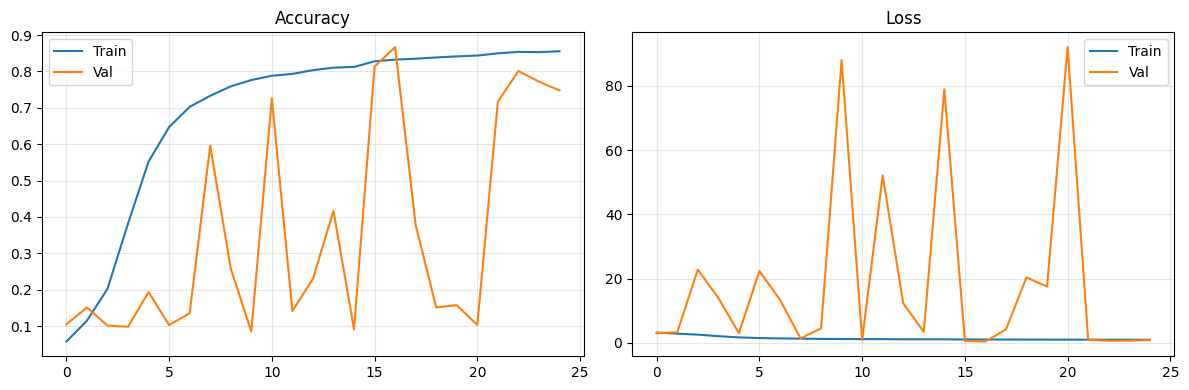

              precision    recall  f1-score   support

         ain       0.00      0.00      0.00       120
        alef       0.00      0.00      0.00       120
         beh       0.00      0.00      0.00       120
         dad       0.00      0.00      0.00       120
         dal       0.00      0.00      0.00       120
         feh       0.00      0.00      0.00       120
       ghain       0.00      0.00      0.00       120
         hah       0.00      0.00      0.00       120
         heh       0.03      0.03      0.03       120
        jeem       0.00      0.00      0.00       120
         kaf       0.00      0.00      0.00       120
        khah       0.00      0.00      0.00       120
         lam       0.08      0.05      0.06       120
        meem       0.00      0.00      0.00       120
        noon       0.00      0.00      0.00       120
         qaf       0.00      0.00      0.00       120
         reh       0.00      0.00      0.00       120
         sad       0.00    

f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [13]:
# Plot history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Classification report
preds = np.argmax(model.predict(test, verbose=0), axis=1)
print(classification_report(test_labels, preds, target_names=ARABIC_LABELS))

## 4. Train YOLO — Single-Class Character Detector
Uses your 73 annotated word images. YOLO only needs to find WHERE characters are — CNN handles what they ARE.

In [14]:
# Convert all label files to single class (class_id = 0)
def convert_to_single_class(dataset_dir):
    for split in ['train', 'val']:
        labels_dir = Path(dataset_dir) / split / 'labels'
        if not labels_dir.exists():
            continue
        count = 0
        for txt in labels_dir.glob('*.txt'):
            lines = txt.read_text().splitlines()
            new_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    parts[0] = '0'
                    new_lines.append(' '.join(parts))
            txt.write_text('\n'.join(new_lines) + '\n')
            count += 1
        print(f"  {split}: converted {count} files")

print("Converting to single-class...")
convert_to_single_class(MY_DATASET)

train_imgs = list((MY_DATASET / 'train' / 'images').glob('*.*'))
val_imgs   = list((MY_DATASET / 'val'   / 'images').glob('*.*'))
print(f"Train: {len(train_imgs)} images   Val: {len(val_imgs)} images")

Converting to single-class...
  train: converted 60 files
  val: converted 13 files
Train: 60 images   Val: 13 images


In [15]:
# Write data.yaml
yaml_path = MY_DATASET / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(f"path: {MY_DATASET.as_posix()}\n")
    f.write("train: train/images\n")
    f.write("val: val/images\n")
    f.write("nc: 1\n")
    f.write("names:\n  - character\n")
print(open(yaml_path).read())

path: F:/bach2/Arabic-Handwritten-Characters-Recognition-using-CNN/my_dataset
train: train/images
val: val/images
nc: 1
names:
  - character



In [16]:
# Train YOLO
yolo_model = YOLO('yolov8s.pt')
yolo_model.train(
    data=str(yaml_path),
    epochs=150,
    imgsz=640,
    batch=4,
    patience=30,
    device='cpu',
    project=str(ROOT / 'my_yolo'),
    name='char_detector',
    exist_ok=True,
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    shear=3.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0,
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
)

YOLO_WEIGHTS = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'
print(f"\nYOLO done. Weights exist: {YOLO_WEIGHTS.exists()}")

New https://pypi.org/project/ultralytics/8.4.30 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.26  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0

## 5. Inference Pipeline
The preprocessing here is **identical** to the working isolated character notebook — this is the key to accuracy.

In [17]:
YOLO_WEIGHTS  = ROOT / 'my_yolo' / 'char_detector' / 'weights' / 'best.pt'

cnn_model     = load_model('arabic_cnn_combined.keras')
yolo_detector = YOLO(str(YOLO_WEIGHTS))
label_classes = np.load('label_classes_combined.npy', allow_pickle=True)

print(f"CNN loaded: arabic_cnn_combined.keras ({len(label_classes)} classes)")
print(f"YOLO loaded: {YOLO_WEIGHTS}")

CNN loaded: arabic_cnn_combined.keras (28 classes)
YOLO loaded: F:\bach2\Arabic-Handwritten-Characters-Recognition-using-CNN\my_yolo\char_detector\weights\best.pt


In [18]:
import os
print(os.getcwd())
import glob
print(glob.glob("*.npy"))

f:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN
['label_classes.npy', 'label_classes_combined.npy']


In [19]:
def preprocess_crop_for_cnn(crop_bgr):
    """
    Exact same preprocessing as the working isolated character notebook.
    Input : BGR crop from YOLO bounding box
    Output: (1, 32, 32, 3) normalized float32 ready for CNN
    """
    # A. Grayscale + Gaussian blur
    gray    = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # B. Otsu threshold → white ink on black background
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # C. Find all ink contours (letter body + dots)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    # D. Bounding box wrapping all ink pieces
    x_min, y_min = np.inf,  np.inf
    x_max, y_max = -np.inf, -np.inf
    for c in cnts:
        if cv2.contourArea(c) > 10:
            x, y, w, h = cv2.boundingRect(c)
            x_min, y_min = min(x_min, x),     min(y_min, y)
            x_max, y_max = max(x_max, x + w), max(y_max, y + h)

    if np.isinf(x_min):
        return None

    # E. Crop ROI
    roi = thresh[int(y_min):int(y_max), int(x_min):int(x_max)]
    if roi.size == 0:
        return None

    # F. Square padding (40% margin — same as working notebook)
    h, w  = roi.shape
    side  = int(max(h, w) * 1.4)
    canvas = np.zeros((side, side), dtype='uint8')
    off_x  = (side - w) // 2
    off_y  = (side - h) // 2
    canvas[off_y:off_y+h, off_x:off_x+w] = roi

    # G. Resize to 64x64 grayscale, normalise
    resized    = cv2.resize(canvas, (64, 64), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    return np.expand_dims(normalized[..., np.newaxis], axis=0)  # (1, 64, 64, 1)


def recognize_word(image_path, conf_threshold=0.25, iou_threshold=0.4):
    """
    Full pipeline:
      1. YOLO detects character bounding boxes
      2. Each crop is preprocessed identically to the isolated-char notebook
      3. CNN classifies each crop
      4. Sorted right-to-left (Arabic reading order)
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    H, W   = img.shape[:2]
    annotated = img.copy()

    # Step 1: YOLO detection
    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]
    boxes   = results.boxes

    if len(boxes) == 0:
        print("No characters detected by YOLO.")
        return [], annotated

    detections = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(W, x2), min(H, y2)
        crop = img[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            continue

        # Step 2 & 3: Preprocess + CNN classify
        inp = preprocess_crop_for_cnn(crop)
        if inp is None:
            continue

        preds    = cnn_model.predict(inp, verbose=0)[0]
        idx      = np.argmax(preds)
        label = str(label_classes[idx]).split('_')[0]
        conf     = float(preds[idx])

        detections.append((x1, y1, x2, y2, label, conf))

    # Step 4: Sort right-to-left
    detections.sort(key=lambda d: -d[0])

    chars = []
    for (x1, y1, x2, y2, label, conf) in detections:
        chars.append(label)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(annotated, f"{label} {conf:.0%}",
                    (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 0), 1)

    return chars, annotated


print("Inference pipeline ready.")

Inference pipeline ready.



Detected characters (right → left): ['sheen', 'sheen', 'sheen']
Word: sheen sheen sheen


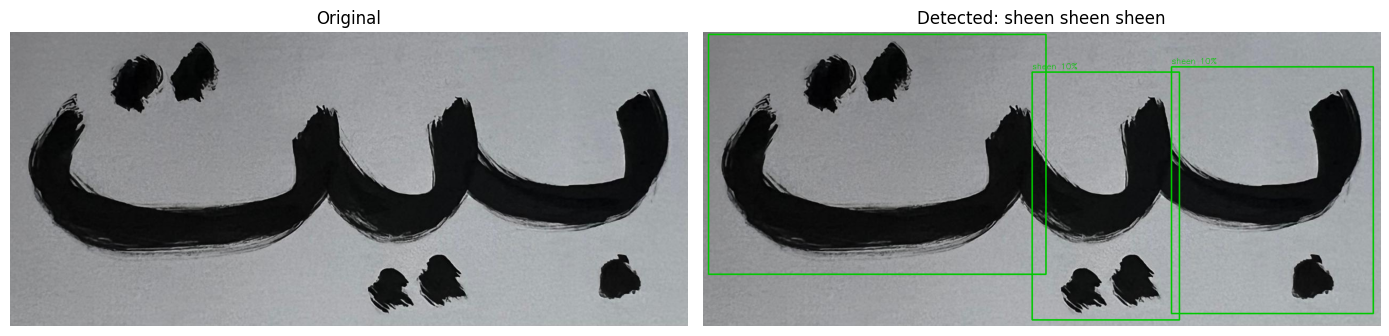

In [20]:
# ── Test on a single word image ───────────────────────────────
# Replace with your image path
TEST_IMAGE = str(ROOT / 'word_test.png')

chars, annotated = recognize_word(TEST_IMAGE, conf_threshold=0.25, iou_threshold=0.4)

print(f"\nDetected characters (right → left): {chars}")
print(f"Word: {' '.join(chars)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEST_IMAGE), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detected: {" ".join(chars)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Testing on 13 val images...

ce0882a8-WhatsApp_Image_2026-03-23_at_2.21.24_AM_8.jpeg: sheen sheen sheen


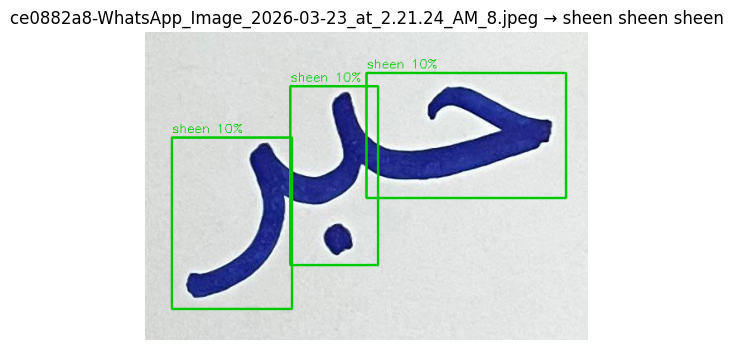

d272ef07-WhatsApp_Image_2026-03-23_at_2.21.26_AM_25.jpeg: sheen sheen sheen


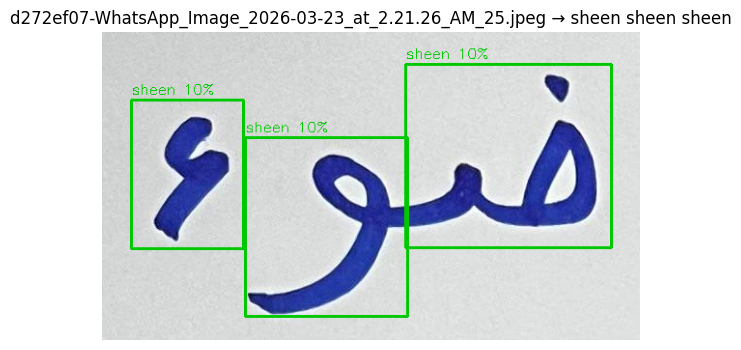

da1fee74-WhatsApp_Image_2026-03-23_at_2.21.26_AM_18.jpeg: sheen sheen sheen


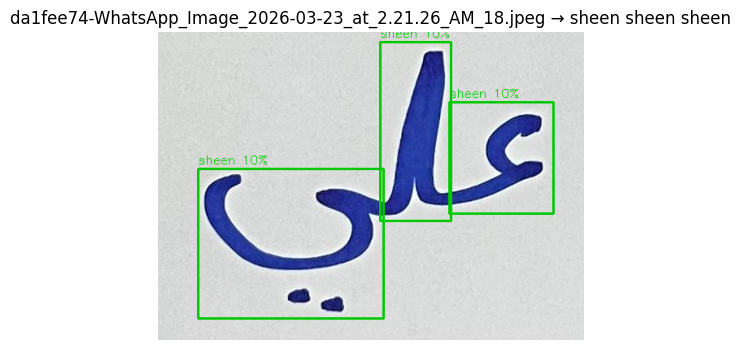

dd921431-WhatsApp_Image_2026-03-23_at_2.21.26_AM_20.jpeg: sheen sheen sheen sheen


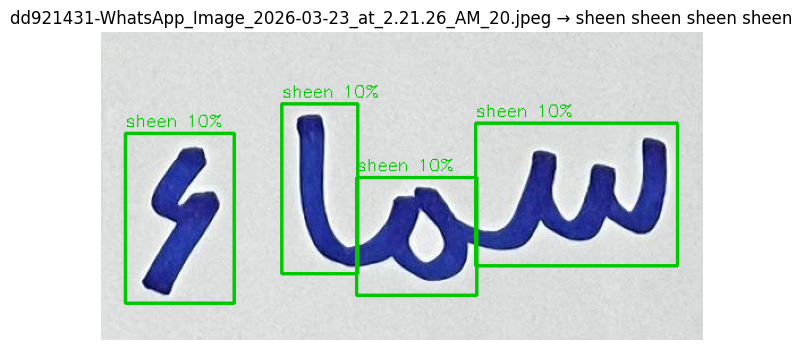

e05f66fa-WhatsApp_Image_2026-03-23_at_2.21.26_AM_9.jpeg: sheen sheen sheen


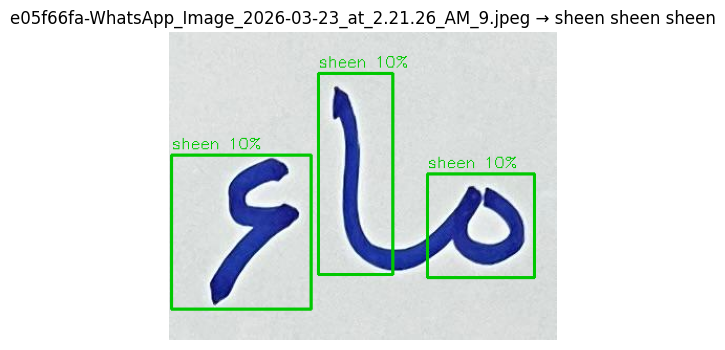

e47bdbbb-WhatsApp_Image_2026-03-23_at_2.21.26_AM_47.jpeg: sheen sheen


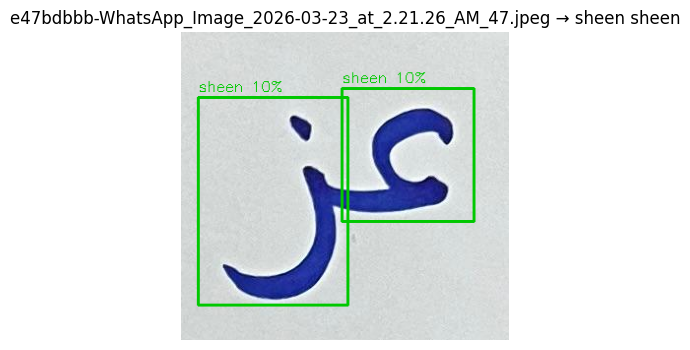

e8f36542-WhatsApp_Image_2026-03-23_at_2.21.26_AM_21.jpeg: sheen sheen sheen


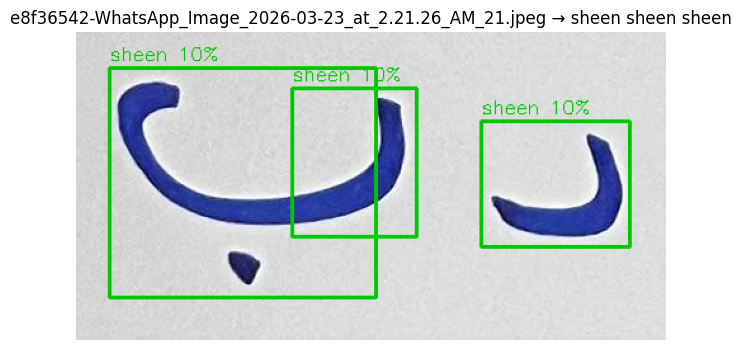

ee3eef31-WhatsApp_Image_2026-03-23_at_2.21.26_AM_40.jpeg: sheen sheen sheen


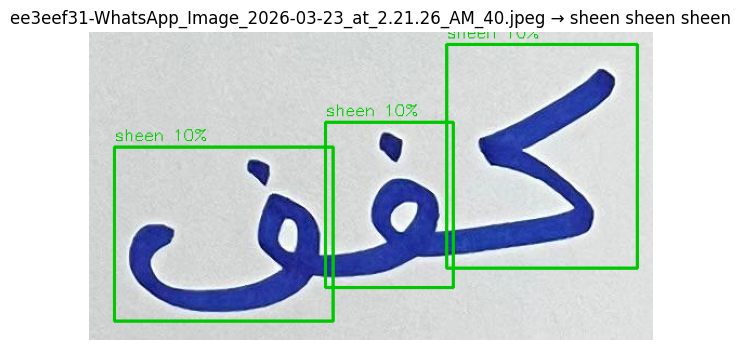

ef978434-WhatsApp_Image_2026-03-23_at_2.21.24_AM_1.jpeg: sheen sheen sheen


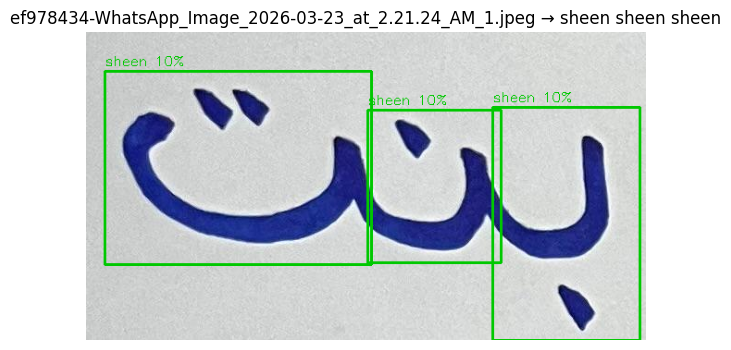

f1769f84-WhatsApp_Image_2026-03-23_at_2.21.26_AM_11.jpeg: sheen sheen sheen


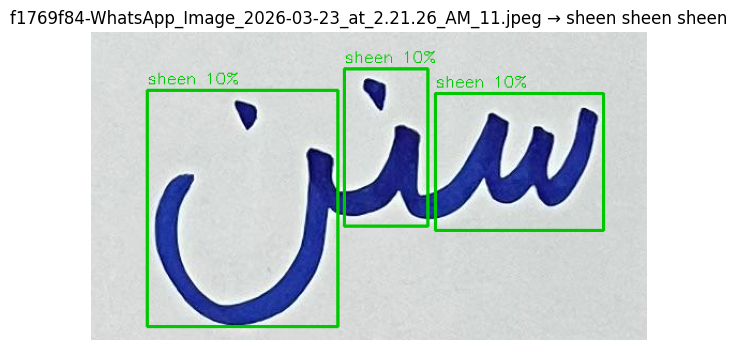

f2491bc4-WhatsApp_Image_2026-03-23_at_2.21.24_AM_3.jpeg: sheen sheen sheen


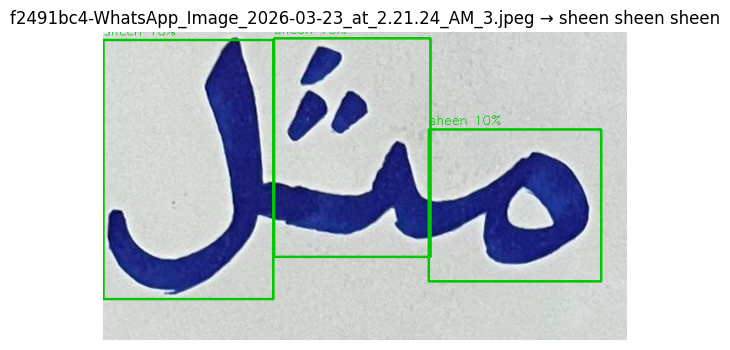

f84cf9b6-WhatsApp_Image_2026-03-23_at_2.21.26_AM_46.jpeg: sheen sheen sheen sheen


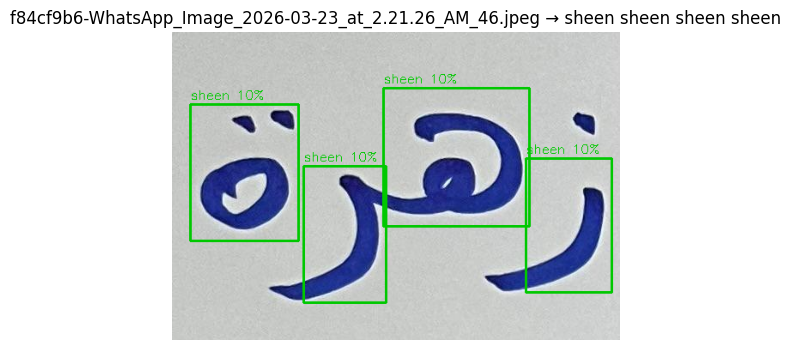

ffef08bc-WhatsApp_Image_2026-03-23_at_2.21.26_AM_34.jpeg: sheen sheen sheen


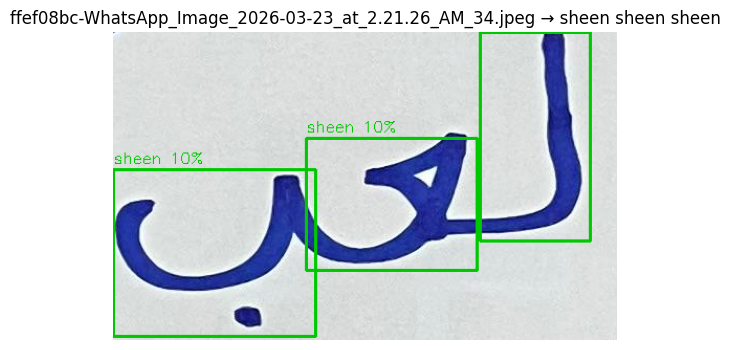

In [21]:
# ── Test on all val images ────────────────────────────────────
val_images = list((MY_DATASET / 'val' / 'images').glob('*.*'))
print(f"Testing on {len(val_images)} val images...\n")

for img_path in val_images:
    try:
        chars, annotated = recognize_word(str(img_path), conf_threshold=0.25)
        print(f"{img_path.name}: {' '.join(chars)}")
        plt.figure(figsize=(10, 4))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title(f"{img_path.name} → {' '.join(chars)}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error on {img_path.name}: {e}")

YOLO found 3 boxes


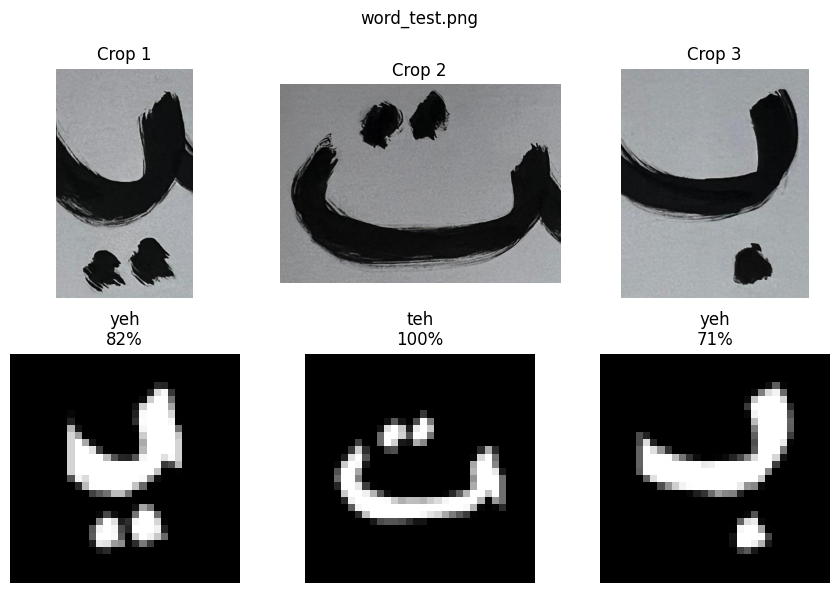

In [39]:
# ── Debug: visualise crops and CNN predictions ────────────────
def debug_word(image_path, conf_threshold=0.25, iou_threshold=0.4):
    img  = cv2.imread(str(image_path))
    H, W = img.shape[:2]
    results = yolo_detector(img, conf=conf_threshold, iou=iou_threshold, verbose=False)[0]
    boxes   = results.boxes
    print(f"YOLO found {len(boxes)} boxes")

    n = len(boxes)
    if n == 0:
        return
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    if n == 1:
        axes = [[axes[0]], [axes[1]]]

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = img[max(0,y1):min(H,y2), max(0,x1):min(W,x2)]
        inp  = preprocess_crop_for_cnn(crop)

        axes[0][i].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[0][i].set_title(f'Crop {i+1}'); axes[0][i].axis('off')

        if inp is not None:
            axes[1][i].imshow(inp[0], cmap='gray' if inp[0].shape[-1]==1 else None)
            preds = cnn_model.predict(inp, verbose=0)[0]
            idx   = np.argmax(preds)
            axes[1][i].set_title(f"{ARABIC_LABELS[idx]}\n{preds[idx]:.0%}")
        else:
            axes[1][i].set_title('None')
        axes[1][i].axis('off')

    plt.suptitle(Path(image_path).name)
    plt.tight_layout()
    plt.show()

# Run on your test image
debug_word(TEST_IMAGE)